In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
%matplotlib inline

print("Libraries loaded successfully")


Libraries loaded successfully


In [3]:
#Load the dataset
df = pd.read_csv('../data/raw/creditcard.csv')

print(f"Shape: {df.shape}")
print(f"\nNull values:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")

Shape: (284807, 31)

Null values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: obj

Normal transactions: 284,315
Fraud transactions:  492

Normal: 99.8273%
Fraud:  0.1727%


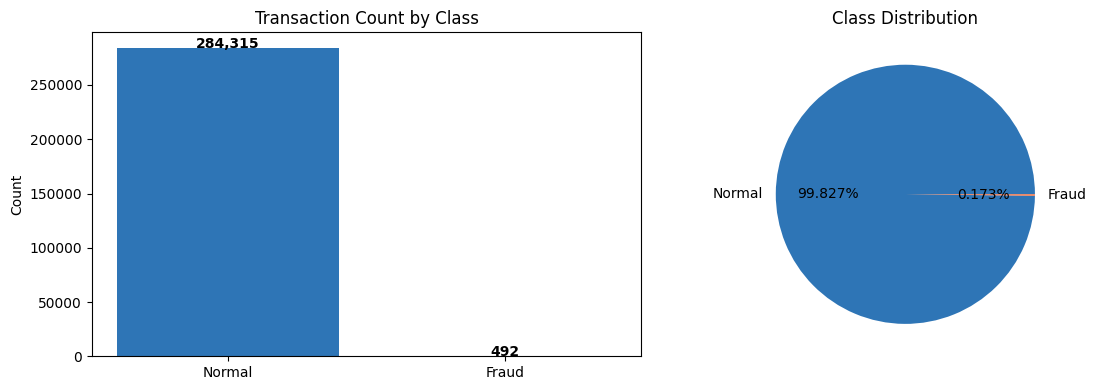

In [4]:
# Class distribution - how many fraud vs normal
class_counts = df['Class'].value_counts()
class_pct = df['Class'].value_counts(normalize=True) * 100

print(f"Normal transactions: {class_counts[0]:,}")
print(f"Fraud transactions:  {class_counts[1]:,}")
print(f"\nNormal: {class_pct[0]:.4f}%")
print(f"Fraud:  {class_pct[1]:.4f}%")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
axes[0].bar(['Normal', 'Fraud'], class_counts.values, 
            color=['#2E75B6', '#FF6B35'])
axes[0].set_title('Transaction Count by Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

# Percentage plot
axes[1].pie(class_counts.values, labels=['Normal', 'Fraud'],
            colors=['#2E75B6', '#FF6B35'], autopct='%1.3f%%')
axes[1].set_title('Class Distribution')

plt.tight_layout()
plt.savefig('../reports/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

AMOUNT STATISTICS

Overall Amount stats:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Fraud Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64

Normal Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64


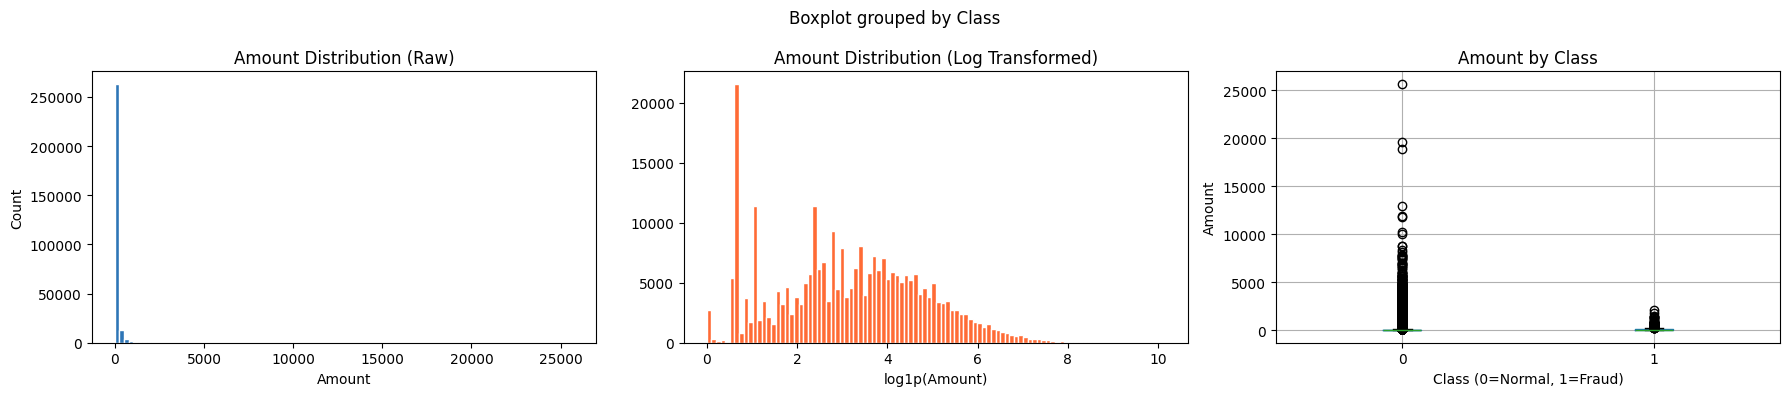

In [5]:
# Amount distribution analysis
print("=" * 50)
print("AMOUNT STATISTICS")
print("=" * 50)
print(f"\nOverall Amount stats:")
print(df['Amount'].describe())

print(f"\nFraud Amount stats:")
print(df[df['Class']==1]['Amount'].describe())

print(f"\nNormal Amount stats:")
print(df[df['Class']==0]['Amount'].describe())

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Distribution of Amount
axes[0].hist(df['Amount'], bins=100, color='#2E75B6', edgecolor='white')
axes[0].set_title('Amount Distribution (Raw)')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Count')

# Log transformed Amount
axes[1].hist(np.log1p(df['Amount']), bins=100, 
             color='#FF6B35', edgecolor='white')
axes[1].set_title('Amount Distribution (Log Transformed)')
axes[1].set_xlabel('log1p(Amount)')

# Amount by class - box plot
df.boxplot(column='Amount', by='Class', ax=axes[2])
axes[2].set_title('Amount by Class')
axes[2].set_xlabel('Class (0=Normal, 1=Fraud)')
axes[2].set_ylabel('Amount')

plt.tight_layout()
plt.savefig('../reports/amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

TIME STATISTICS
count    284807.000000
mean      94813.859575
std       47488.145955
min           0.000000
25%       54201.500000
50%       84692.000000
75%      139320.500000
max      172792.000000
Name: Time, dtype: float64


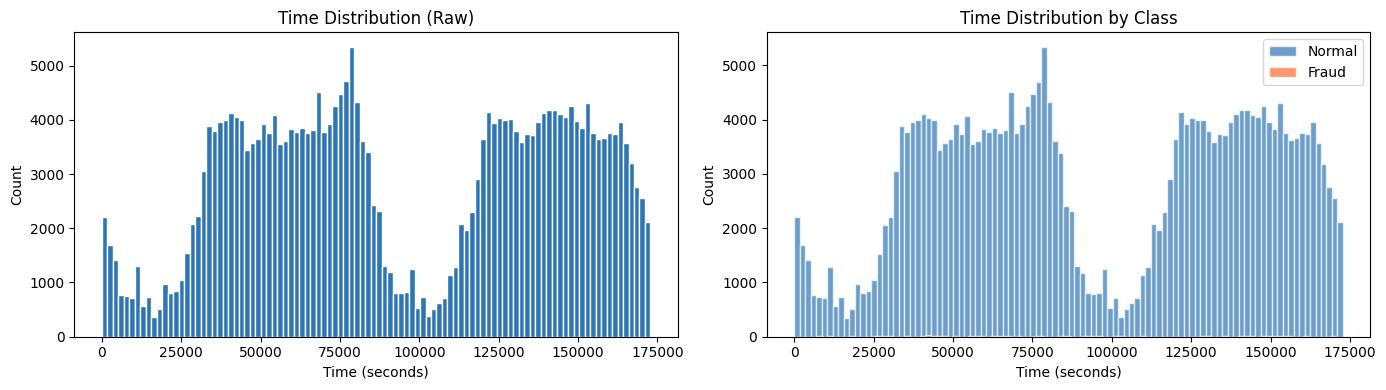

In [6]:
# Time distribution analysis
print("=" * 50)
print("TIME STATISTICS")
print("=" * 50)
print(df['Time'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw time distribution
axes[0].hist(df['Time'], bins=100, 
             color='#2E75B6', edgecolor='white')
axes[0].set_title('Time Distribution (Raw)')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Count')

# Time by class
axes[1].hist(df[df['Class']==0]['Time'], bins=100,
             alpha=0.7, color='#2E75B6', 
             label='Normal', edgecolor='white')
axes[1].hist(df[df['Class']==1]['Time'], bins=100,
             alpha=0.7, color='#FF6B35',
             label='Fraud', edgecolor='white')
axes[1].set_title('Time Distribution by Class')
axes[1].set_xlabel('Time (seconds)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/time_distribution.png', 
            dpi=150, bbox_inches='tight')
plt.show()

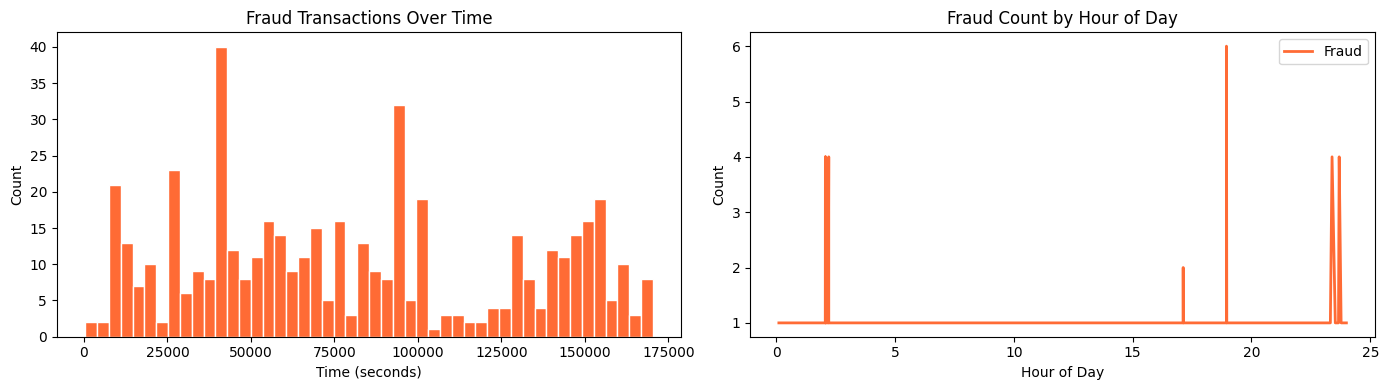

In [7]:
# Zoom into fraud timing
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Fraud transactions over time
axes[0].hist(df[df['Class']==1]['Time'], 
             bins=48, color='#FF6B35', edgecolor='white')
axes[0].set_title('Fraud Transactions Over Time')
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Count')

# Hour of day conversion
df['Hour'] = (df['Time'] / 3600) % 24
fraud_by_hour = df[df['Class']==1]['Hour'].value_counts().sort_index()
normal_by_hour = df[df['Class']==0]['Hour'].value_counts().sort_index()

# Fraud rate by hour
axes[1].plot(fraud_by_hour.index, fraud_by_hour.values,
             color='#FF6B35', label='Fraud', linewidth=2)
axes[1].set_title('Fraud Count by Hour of Day')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/time_fraud_analysis.png',
            dpi=150, bbox_inches='tight')
plt.show()

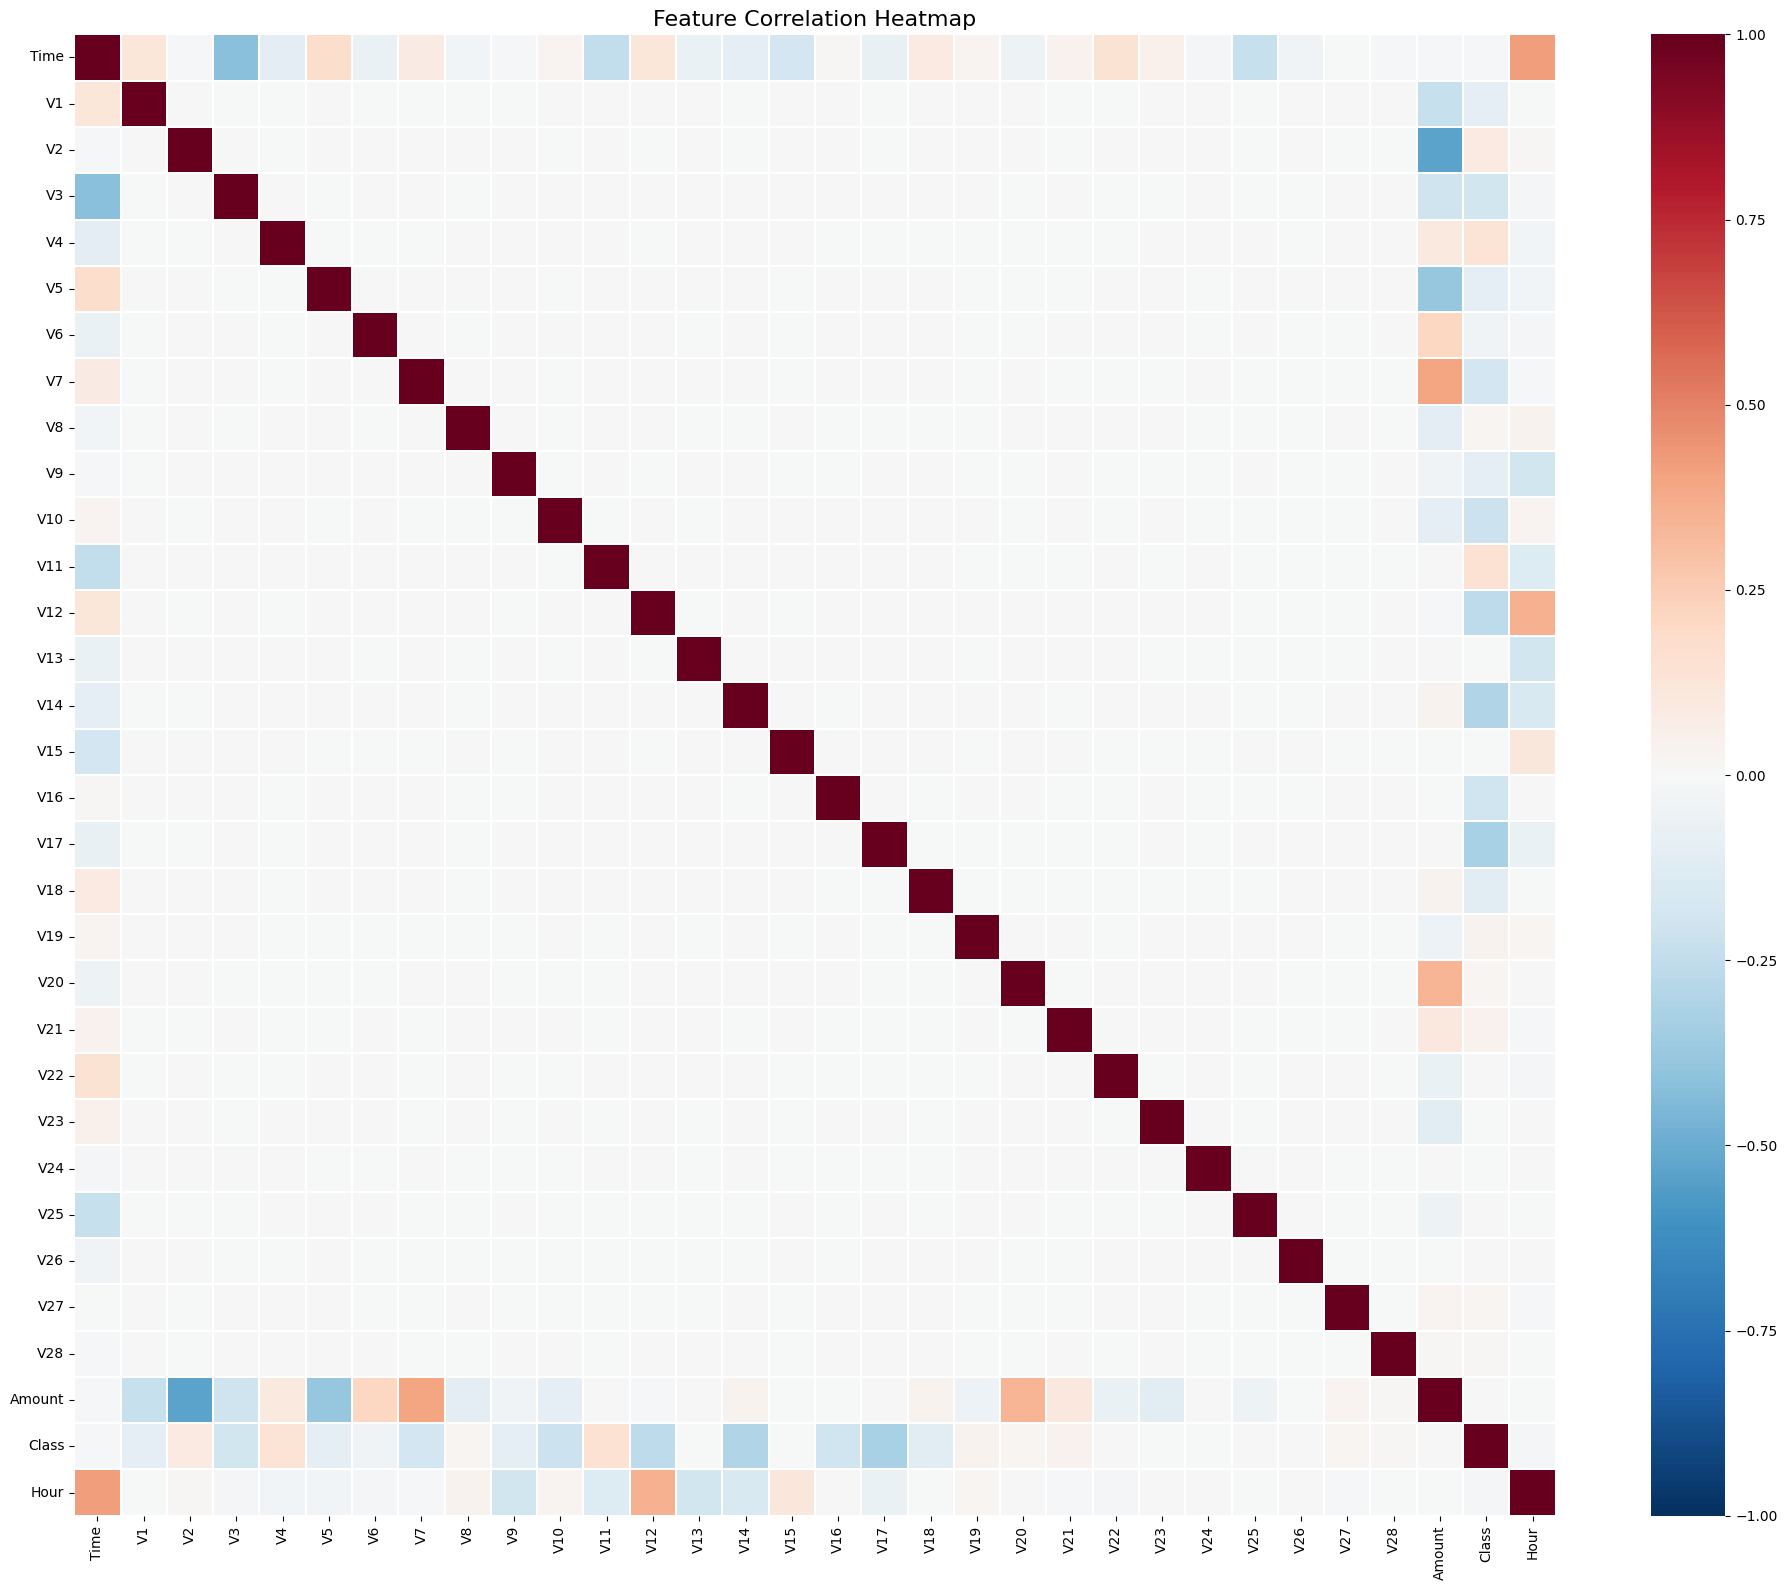

Top correlations with fraud (Class):
Class    1.000000
V17      0.326481
V14      0.302544
V12      0.260593
V10      0.216883
V16      0.196539
V3       0.192961
V7       0.187257
V11      0.154876
V4       0.133447
V18      0.111485
V1       0.101347
V9       0.097733
V5       0.094974
V2       0.091289
Name: Class, dtype: float64


In [8]:
# Correlation heatmap
plt.figure(figsize=(20, 16))

correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, 
            cmap='RdBu_r',
            center=0,
            vmin=-1, vmax=1,
            square=True,
            linewidths=0.1,
            annot=False)

plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', 
            dpi=150, bbox_inches='tight')
plt.show()

# Print top correlations with Class
print("Top correlations with fraud (Class):")
class_corr = correlation_matrix['Class'].abs().sort_values(ascending=False)
print(class_corr.head(15))

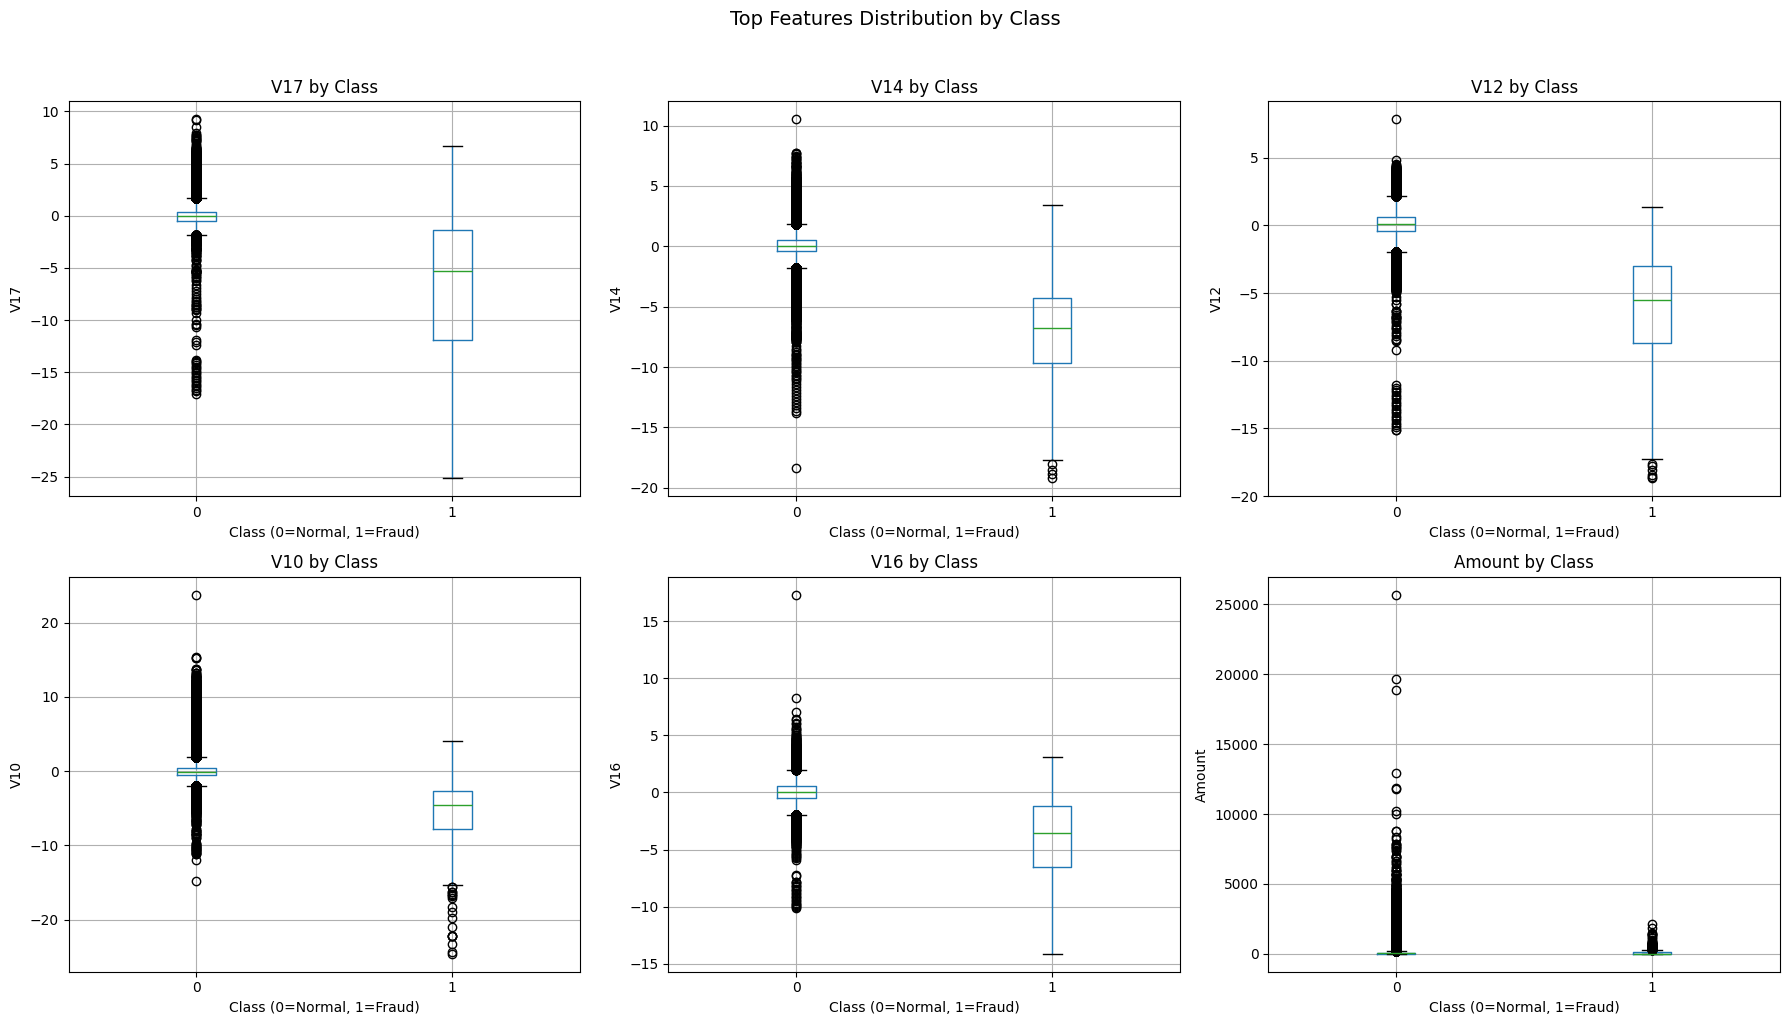

In [9]:
# Box plots for top features by class
top_features = ['V17', 'V14', 'V12', 'V10', 'V16', 'Amount']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feature in enumerate(top_features):
    df.boxplot(column=feature, by='Class', ax=axes[i])
    axes[i].set_title(f'{feature} by Class')
    axes[i].set_xlabel('Class (0=Normal, 1=Fraud)')
    axes[i].set_ylabel(feature)

plt.suptitle('Top Features Distribution by Class', 
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../reports/feature_boxplots.png',
            dpi=150, bbox_inches='tight')
plt.show()

## EDA Summary & Feature Engineering Plan

### Dataset Overview
- **Shape:** 284,807 transactions × 31 features
- **Missing values:** None
- **Class imbalance:** 99.83% normal / 0.17% fraud (492 cases)

### Key Findings

| Feature | Finding | Action |
|---------|---------|--------|
| `Amount` | Right-skewed (mean $88, median $22, max $25,519) | Apply `log1p` |
| `Time` | Bimodal distribution (two daily peaks) | Normalize to [0, 1] |
| `V1–V28` | PCA components, uncorrelated with each other | Keep all |
| `V17, V14, V12` | Highest correlation with fraud label | Top model features |

### Modeling Decisions
1. **Metric:** PR-AUC (not accuracy) — class imbalance makes accuracy meaningless
2. **Imbalance handling:** SMOTE on training data only, after split
3. **Feature engineering:** log1p(Amount), normalize Time, keep all V features

### Next Step → Feature Engineering